In [47]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#23456789
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import SGD

## Initializing Tensors

In [2]:
x = torch.tensor([[1, 2]])
y = torch.tensor([[1], [2]])
print(x.shape)
print(y.shape)
print(x.dtype)

torch.Size([1, 2])
torch.Size([2, 1])
torch.int64


In [3]:
x = torch.tensor([False, 1, 2.])
x

tensor([0., 1., 2.])

In [4]:
torch.zeros((3, 4))

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [5]:
torch.ones((2, 3))

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [6]:
torch.randint(low=0, high=10, size=(3, 2))

tensor([[0, 2],
        [3, 7],
        [2, 4]])

In [7]:
torch.rand(2, 4)

tensor([[0.6323, 0.8965, 0.0449, 0.9657],
        [0.3024, 0.6596, 0.2285, 0.5836]])

In [8]:
torch.randn((3, 4))  # normal

tensor([[-1.3473,  0.2405, -1.2291, -1.1951],
        [-1.9191,  2.0482,  2.6244, -0.8089],
        [-2.1232, -1.8083, -1.0489, -1.8290]])

In [9]:
x = np.array([[10, 20, 30], [2, 3, 4]])
y = torch.tensor(x)
y

tensor([[10, 20, 30],
        [ 2,  3,  4]])

In [10]:
type(x), type(y)

(numpy.ndarray, torch.Tensor)

## Operations on Tensors

In [11]:
x = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])
10 * x

tensor([[10, 20, 30, 40],
        [50, 60, 70, 80]])

In [12]:
y = x + 10
y

tensor([[11, 12, 13, 14],
        [15, 16, 17, 18]])

In [13]:
y.shape

torch.Size([2, 4])

In [14]:
y = y.view(4, 2)  # reshape
y

tensor([[11, 12],
        [13, 14],
        [15, 16],
        [17, 18]])

In [15]:
x = torch.randn(3, 1, 3)
z1 =  torch.squeeze(x, 1)
z2 = torch.squeeze(x)  # only one possible dim to squeeze out
x.shape, z1.shape, z2.shape

(torch.Size([3, 1, 3]), torch.Size([3, 3]), torch.Size([3, 3]))

In [16]:
x = torch.randn(3, 3)
z1 = x.unsqueeze(0)
z2 = x.unsqueeze(1)
x.shape, z1.shape, z2.shape

(torch.Size([3, 3]), torch.Size([1, 3, 3]), torch.Size([3, 1, 3]))

In [17]:
x = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])
x @ y

tensor([[150, 160],
        [374, 400]])

In [18]:
torch.matmul(x, y)

tensor([[150, 160],
        [374, 400]])

In [19]:
x = torch.randn(10, 10, 10)
z1 = torch.cat([x, x], axis=0)
z2 = torch.cat([x, x], axis=1)
z1.shape, z2.shape

(torch.Size([20, 10, 10]), torch.Size([10, 20, 10]))

In [20]:
x = torch.arange(25).reshape(5, 5)
x.max()

tensor(24)

In [21]:
x.max(dim=0)

torch.return_types.max(
values=tensor([20, 21, 22, 23, 24]),
indices=tensor([4, 4, 4, 4, 4]))

In [22]:
m, argm = x.max(dim=1)
m, argm

(tensor([ 4,  9, 14, 19, 24]), tensor([4, 4, 4, 4, 4]))

In [23]:
x = torch.randn(10, 20, 30)
z = x.permute(2, 0, 1)
x.shape, z.shape

(torch.Size([10, 20, 30]), torch.Size([30, 10, 20]))

## Auto Gradients of Tensor Objects

In [24]:
x = torch.tensor([[2., -1.], [1., 1.]], requires_grad=True)
x

tensor([[ 2., -1.],
        [ 1.,  1.]], requires_grad=True)

In [25]:
out = x.pow(2).sum()  # sum of squares
out.backward()
x.grad

tensor([[ 4., -2.],
        [ 2.,  2.]])

out = x^2; grad = 2x

## Advantages of PyTorch's Tensors over Numpy's `ndarray`s

In [26]:
x = torch.rand(1, 6400)
y = torch.rand(6400, 5000)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [27]:
x, y = x.to(device), y.to(device)

In [28]:
%%timeit
z = x @ y

5.82 ms ± 301 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [29]:
x = np.random.random((1, 6400))
y = np.random.random((6400, 5000))

In [30]:
%%timeit
z = x @ y

6.68 ms ± 157 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Building a Neural Netwerk with PyTorch

In [31]:
x = [[1, 2], [3, 4], [5, 6], [7, 8]]
y = [[3], [7], [11], [15]]

In [32]:
X = torch.tensor(x).float()
y = torch.tensor(y).float()

In [33]:
X = X.to(device)
y = y.to(device)

In [34]:
class MyNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2, 8)
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Linear(8, 1)

    def forward(self, x):
        x = self.input_to_hidden_layer(x)
        x = self.hidden_layer_activation(x)
        x = self.hidden_to_output_layer(x)
        return x

In [35]:
my_net = MyNN().to(device)

In [36]:
my_net.input_to_hidden_layer.weight

Parameter containing:
tensor([[-0.6478,  0.0158],
        [-0.2428,  0.1775],
        [-0.3927, -0.6356],
        [ 0.1455,  0.4895],
        [ 0.0800, -0.3005],
        [-0.0289,  0.0244],
        [-0.5553, -0.2954],
        [-0.4643, -0.3130]], requires_grad=True)

In [37]:
my_net.parameters()

<generator object Module.parameters at 0x1088ea260>

In [38]:
for p in my_net.parameters():
    print(p)

Parameter containing:
tensor([[-0.6478,  0.0158],
        [-0.2428,  0.1775],
        [-0.3927, -0.6356],
        [ 0.1455,  0.4895],
        [ 0.0800, -0.3005],
        [-0.0289,  0.0244],
        [-0.5553, -0.2954],
        [-0.4643, -0.3130]], requires_grad=True)
Parameter containing:
tensor([ 0.4787, -0.4390,  0.2008, -0.1824,  0.1213, -0.1790,  0.1871,  0.5046],
       requires_grad=True)
Parameter containing:
tensor([[-0.0815, -0.1076, -0.2403, -0.3173, -0.0785, -0.1023,  0.0245,  0.2954]],
       requires_grad=True)
Parameter containing:
tensor([0.1751], requires_grad=True)


In [39]:
# аlternate
class MyNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Parameter(torch.rand(2, 8))
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Parameter(torch.rand(8, 1))

    def forward(self, x):
        x = x @ self.input_to_hidden_layer
        x = self.hidden_layer_activation(x)
        x = x @ self.hidden_to_output_layer
        return x

In [40]:
loss_func = nn.MSELoss()

In [41]:
_y = my_net(X)
loss_val = loss_func(_y, y)
loss_val

tensor(118.8746, grad_fn=<MseLossBackward0>)

In [42]:
opt = SGD(my_net.parameters(), lr=0.001)

In [43]:
# illustration
opt.zero_grad() 
loss_val = loss_func(my_net(X), y)
loss_val

tensor(118.8746, grad_fn=<MseLossBackward0>)

In [44]:
loss_val.backward()
opt.step()

In [46]:
loss_history = []
for _ in range(50):
    opt.zero_grad()
    loss_val = loss_func(my_net(X), y)
    loss_val.backward()
    opt.step()
    loss_history.append(loss_val.item())

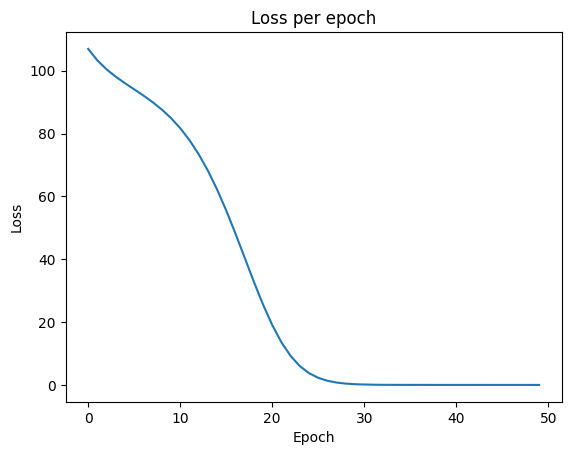

In [48]:
plt.plot(loss_history)
plt.title('Loss per epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss');